In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
# Cell 1 — Setup
import os, torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

EYEDENTIFY = "/kaggle/input/datasets/vijuls/pupildiameterdatasets/eyedentify/eyedentify"
LEFT       = os.path.join(EYEDENTIFY, "left_eyes")
OUTPUT     = "/kaggle/working"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"✓ Device    : {device}")
print(f"✓ GPU       : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"✓ EyeDentify: {os.path.exists(LEFT)}")
print(f"✓ Subjects  : {len(os.listdir(LEFT))}")

✓ Device    : cuda
✓ GPU       : Tesla T4
✓ EyeDentify: True
✓ Subjects  : 51


### Rebuild model + dataset

In [2]:
# config
SEQ_LEN    = 10
IMG_SIZE   = 64
BATCH_SIZE = 32
N_USERS    = 15

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# dataset class
class EyeDentifyDataset(Dataset):
    def __init__(self, left_path, subjects, transform=None,
                 seq_len=10, stride=5, max_per_subject=200):
        self.transform = transform
        self.seq_len   = seq_len
        self.sequences = []
        for label, subject in enumerate(subjects):
            s_path   = os.path.join(left_path, subject)
            sessions = sorted(os.listdir(s_path))
            seq_count = 0
            for session in sessions:
                ses_path = os.path.join(s_path, session)
                if not os.path.isdir(ses_path): continue
                frames = sorted([
                    os.path.join(ses_path, f)
                    for f in os.listdir(ses_path) if f.endswith('.png')
                ])
                for start in range(0, len(frames)-seq_len+1, stride):
                    self.sequences.append((frames[start:start+seq_len], label))
                    seq_count += 1
                    if seq_count >= max_per_subject: break
                if seq_count >= max_per_subject: break
    def __len__(self): return len(self.sequences)
    def __getitem__(self, idx):
        frame_paths, label = self.sequences[idx]
        frames = []
        for path in frame_paths:
            img = Image.open(path).convert('RGB')
            if self.transform: img = self.transform(img)
            frames.append(img)
        return torch.stack(frames), label

subjects    = sorted(os.listdir(LEFT))[:N_USERS]
full_dataset = EyeDentifyDataset(LEFT, subjects, transform=transform,
                                  seq_len=SEQ_LEN, stride=5, max_per_subject=200)

indices = list(range(len(full_dataset)))
labels  = [full_dataset.sequences[i][1] for i in indices]
train_idx, temp_idx = train_test_split(indices, test_size=0.3, random_state=42, stratify=labels)
temp_labels = [labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42, stratify=temp_labels)

test_dataset = Subset(full_dataset, test_idx)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"✓ Test dataset : {len(test_dataset):,} sequences")
print(f"✓ Test batches : {len(test_loader):,}")

✓ Test dataset : 450 sequences
✓ Test batches : 15


### Rebuild and retrain model

In [3]:
class CNNFeatureExtractor(nn.Module):
    def __init__(self, img_size=64):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.out_dim = 128
    def forward(self, x):
        return self.features(x).view(x.size(0), -1)

class EyeMotionID(nn.Module):
    def __init__(self, n_users=15, img_size=64, hidden_size=256, num_layers=2, dropout=0.5):
        super().__init__()
        self.cnn = CNNFeatureExtractor(img_size)
        self.lstm = nn.LSTM(self.cnn.out_dim, hidden_size, num_layers,
                            batch_first=True, dropout=dropout if num_layers>1 else 0)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, n_users)
    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B*T, C, H, W)
        x = self.cnn(x)
        x = x.view(B, T, -1)
        _, (h, _) = self.lstm(x)
        return self.classifier(self.dropout(h[-1]))

# rebuild full dataset for training
train_dataset = Subset(full_dataset, train_idx)
val_dataset   = Subset(full_dataset, val_idx)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

model     = EyeMotionID(n_users=N_USERS, img_size=IMG_SIZE).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# quick retrain — 30 epochs
import time
print("Retraining model (30 epochs)...")
best_val_acc = 0.0
for epoch in range(1, 31):
    model.train()
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), lbls)
        loss.backward()
        optimizer.step()
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            preds = model(imgs).argmax(dim=1)
            correct += (preds == lbls).sum().item()
            total   += lbls.size(0)
    val_acc = correct / total
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f"{OUTPUT}/best_model.pth")
    if epoch % 5 == 0:
        print(f"  Epoch {epoch}/30 | Val Acc: {val_acc:.2%}")

model.load_state_dict(torch.load(f"{OUTPUT}/best_model.pth"))
print(f"\n✓ Best val accuracy: {best_val_acc:.2%}")

Retraining model (30 epochs)...
  Epoch 5/30 | Val Acc: 59.56%
  Epoch 10/30 | Val Acc: 66.89%
  Epoch 15/30 | Val Acc: 92.00%
  Epoch 20/30 | Val Acc: 96.22%
  Epoch 25/30 | Val Acc: 98.67%
  Epoch 30/30 | Val Acc: 98.22%

✓ Best val accuracy: 99.33%


### Generate predictions on test set

In [4]:
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# overall accuracy
accuracy = (all_preds == all_labels).mean()
print(f"=== Test Set Predictions ===\n")
print(f"Total sequences tested : {len(all_labels):,}")
print(f"Correct predictions    : {(all_preds == all_labels).sum():,}")
print(f"Wrong predictions      : {(all_preds != all_labels).sum():,}")
print(f"Overall accuracy       : {accuracy:.2%}")

=== Test Set Predictions ===

Total sequences tested : 450
Correct predictions    : 445
Wrong predictions      : 5
Overall accuracy       : 98.89%


### Confusion matrix


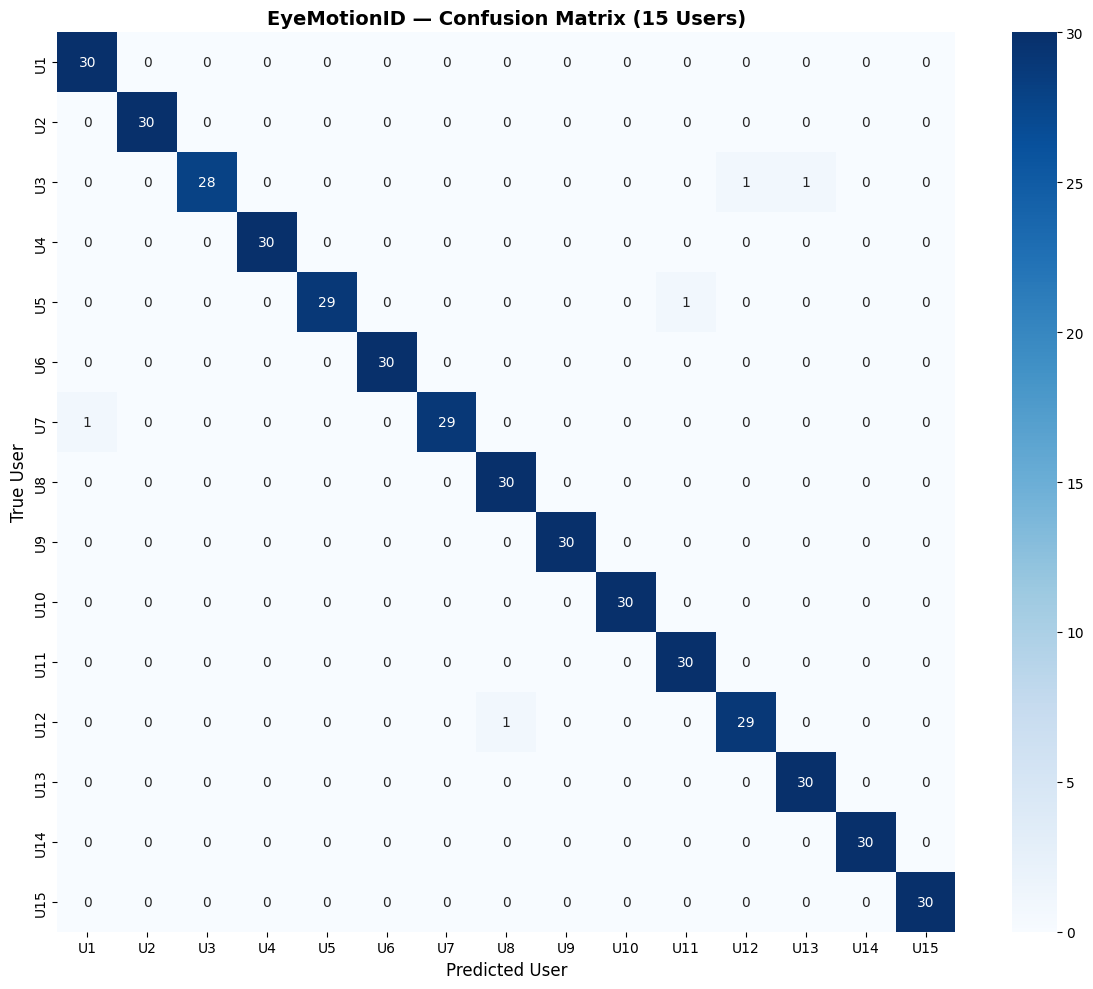

✓ Saved → confusion_matrix.png

=== Per-User Accuracy ===

  User  1 : 100.00% ████████████████████
  User  2 : 100.00% ████████████████████
  User  3 : 93.33% ██████████████████
  User  4 : 100.00% ████████████████████
  User  5 : 96.67% ███████████████████
  User  6 : 100.00% ████████████████████
  User  7 : 96.67% ███████████████████
  User  8 : 100.00% ████████████████████
  User  9 : 100.00% ████████████████████
  User 10 : 100.00% ████████████████████
  User 11 : 100.00% ████████████████████
  User 12 : 96.67% ███████████████████
  User 13 : 100.00% ████████████████████
  User 14 : 100.00% ████████████████████
  User 15 : 100.00% ████████████████████


In [11]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"U{i+1}" for i in range(N_USERS)],
            yticklabels=[f"U{i+1}" for i in range(N_USERS)])
plt.title("EyeMotionID — Confusion Matrix (15 Users)", fontsize=14, fontweight='bold')
plt.ylabel("True User", fontsize=12)
plt.xlabel("Predicted User", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT}/confusion_matrix.png", dpi=600)
plt.show()
print("✓ Saved → confusion_matrix.png")

# per-user accuracy
print("\n=== Per-User Accuracy ===\n")
for i in range(N_USERS):
    user_mask    = all_labels == i
    user_correct = (all_preds[user_mask] == i).sum()
    user_total   = user_mask.sum()
    user_acc     = user_correct / user_total if user_total > 0 else 0
    bar          = "█" * int(user_acc * 20)
    print(f"  User {i+1:2d} : {user_acc:.2%} {bar}")

### Classification report

In [8]:
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score)
print("✓ imports ready")
report = classification_report(
    all_labels, all_preds,
    target_names=[f"User_{i+1}" for i in range(N_USERS)],
    digits=3
)
print("=== Classification Report ===\n")
print(report)

# macro averages
precision = precision_score(all_labels, all_preds, average='macro')
recall    = recall_score(all_labels, all_preds, average='macro')
f1        = f1_score(all_labels, all_preds, average='macro')

print("=== Summary Metrics ===\n")
print(f"Accuracy  : {accuracy:.4f} ({accuracy:.2%})")
print(f"Precision : {precision:.4f} ({precision:.2%})")
print(f"Recall    : {recall:.4f} ({recall:.2%})")
print(f"F1-Score  : {f1:.4f} ({f1:.2%})")

✓ imports ready
=== Classification Report ===

              precision    recall  f1-score   support

      User_1      0.968     1.000     0.984        30
      User_2      1.000     1.000     1.000        30
      User_3      1.000     0.933     0.966        30
      User_4      1.000     1.000     1.000        30
      User_5      1.000     0.967     0.983        30
      User_6      1.000     1.000     1.000        30
      User_7      1.000     0.967     0.983        30
      User_8      0.968     1.000     0.984        30
      User_9      1.000     1.000     1.000        30
     User_10      1.000     1.000     1.000        30
     User_11      0.968     1.000     0.984        30
     User_12      0.967     0.967     0.967        30
     User_13      0.968     1.000     0.984        30
     User_14      1.000     1.000     1.000        30
     User_15      1.000     1.000     1.000        30

    accuracy                          0.989       450
   macro avg      0.989     0.989

### Per-user accuracy bar chart

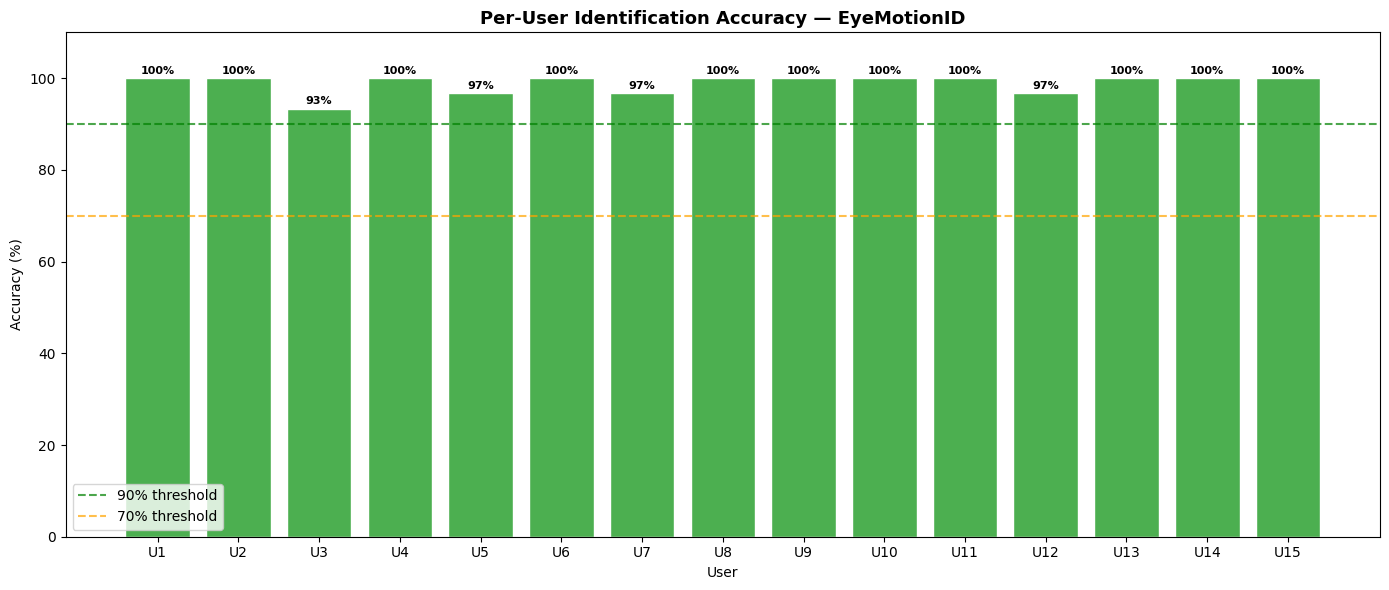

✓ Saved → per_user_accuracy.png


In [10]:
per_user_acc = []
for i in range(N_USERS):
    mask    = all_labels == i
    acc     = (all_preds[mask] == i).mean() if mask.sum() > 0 else 0
    per_user_acc.append(acc * 100)

colors = ['#4CAF50' if a >= 90 else '#FF9800' if a >= 70 else '#F44336'
          for a in per_user_acc]

plt.figure(figsize=(14, 6))
bars = plt.bar([f"U{i+1}" for i in range(N_USERS)],
               per_user_acc, color=colors, edgecolor='white')
plt.axhline(y=90, color='green',  linestyle='--', alpha=0.7, label='90% threshold')
plt.axhline(y=70, color='orange', linestyle='--', alpha=0.7, label='70% threshold')
plt.title("Per-User Identification Accuracy — EyeMotionID",
          fontsize=13, fontweight='bold')
plt.ylabel("Accuracy (%)")
plt.xlabel("User")
plt.ylim(0, 110)
plt.legend(fontsize=10)
for bar, acc in zip(bars, per_user_acc):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f"{acc:.0f}%", ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT}/per_user_accuracy.png", dpi=600)
plt.show()
print("✓ Saved → per_user_accuracy.png")

### Summary

In [13]:
print("=" * 50)
print("   DAY 18 — USER IDENTIFICATION SUMMARY")
print("=" * 50)
print()
print(f"Model     : EyeMotionID (CNN + LSTM)")
print(f"Users     : {N_USERS}")
print(f"Sequences : {len(test_dataset)} test sequences")
print()
print("Performance Metrics:")
print(f"  Accuracy  : {accuracy:.2%}")
print(f"  Precision : {precision:.2%}")
print(f"  Recall    : {recall:.2%}")
print(f"  F1-Score  : {f1:.2%}")
print()
print(f"Best user accuracy : {max(per_user_acc):.1f}%")
print(f"Worst user accuracy: {min(per_user_acc):.1f}%")
print(f"Average accuracy   : {np.mean(per_user_acc):.1f}%")
print()
print("Plots saved:")
print("  ✓ confusion_matrix.png")
print("  ✓ per_user_accuracy.png")
print()

print("=" * 50)

   DAY 18 — USER IDENTIFICATION SUMMARY

Model     : EyeMotionID (CNN + LSTM)
Users     : 15
Sequences : 450 test sequences

Performance Metrics:
  Accuracy  : 98.89%
  Precision : 98.92%
  Recall    : 98.89%
  F1-Score  : 98.88%

Best user accuracy : 100.0%
Worst user accuracy: 93.3%
Average accuracy   : 98.9%

Plots saved:
  ✓ confusion_matrix.png
  ✓ per_user_accuracy.png

